# Proton Analysis

Same idea as `xray_analysis.ipynb`, but for the proton (delayed) feature -- starting with its
onset. Now lives in `shot_characterization/proton.py` (`find_proton_onset()`) -- this
notebook just calls it, along with `find_xray_shape()` from `shot_characterization/xray.py`
for the x-ray reference point.

**Peak**: envelope (heavily boxcar-smoothed) maximum in a window after the x-ray peak,
skipping a short dead-time -- smoothing is needed here to find the true envelope peak rather
than a random noise sample within the noisy hump.

**Onset**: walk backward from the peak, on the envelope, to a threshold that depends on the
proton feature's own shape. Three methods were tried in order:
- A fixed 2-sigma-above-noise threshold never terminated on shot 9 -- the x-ray's decay
  leaves a low-level ringing shoulder that never fully drops back to the pre-trigger noise
  floor before the real proton rise starts, so the backward walk just hit the x-ray peak.
- Walking back to the first local minimum landed *inside* the ringing on shot 9 (onset at
  107.2ns) -- the noisy ringing between the x-ray and the real rise has many small wiggles,
  and the backward walk stopped at the very first one instead of the true edge of the rise.
- A single fixed fraction of peak-envelope-height doesn't work either way: shots 9 and 11
  have a narrow, sharp proton spike (width at 50%-of-peak-height only 3.5-8ns) where 50%
  correctly finds the rise's base, but the rest of the campaign (15, 16, 18-22, 27) has a
  much broader, more gradual ramp (17-36ns wide) where 50% lands partway up the slope --
  10% is needed there instead, but 10% walks too far back into pre-pulse noise on the narrow
  shots 9/11.

**Current approach**: measure the feature's own width at 50% of peak height first, then use
50% as the onset threshold if narrow (<12ns) or 10% if broad. Validated across all 10 usable
shots this way.

**Known issue**: shots 25 and 26 are still broken -- their signal has a positive bump that
transitions into a much bigger negative dip, which confuses the sign-agnostic envelope
search. Not fixed yet.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

import shot_log as sl
from helpers import load_channel
from shot_characterization.characterize import characterize
from shot_characterization import VERIFIED_CATEGORY, find_xray_shape, find_proton_onset


## Check on one shot

shot 9: proton onset=108.666ns  peak=110.510ns  (onset-to-peak = 1.844ns)


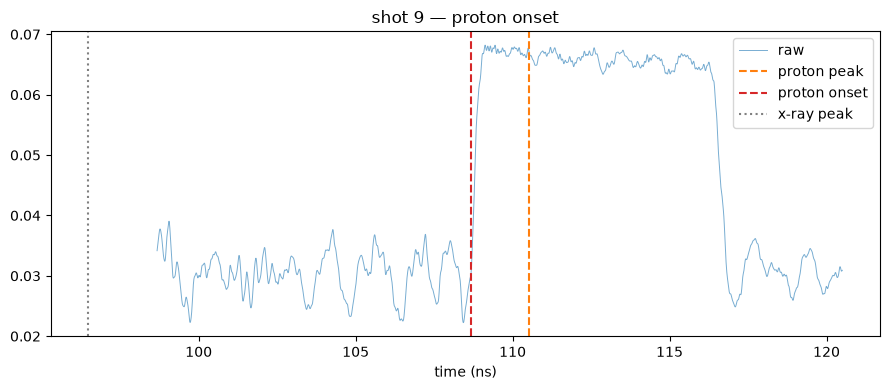

{'peak_i': 78573,
 'onset_i': 78337,
 'peak_time_ns': 110.50998202296681,
 'peak_val_V': 0.06750564816327312,
 'onset_time_ns': 108.6662320229668,
 'onset_val_V': 0.030004795998427286,
 'width50_ns': 7.999999999999957,
 'onset_frac_used': 0.5}

In [2]:
def plot_proton_onset(shot, pad_ns=10):
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    if xr is None:
        print(f"shot {shot}: no x-ray found")
        return None
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    if pr is None:
        print(f"shot {shot}: no proton found")
        return None
    print(f"shot {shot}: proton onset={pr['onset_time_ns']:.3f}ns  peak={pr['peak_time_ns']:.3f}ns"
          f"  (onset-to-peak = {pr['peak_time_ns']-pr['onset_time_ns']:.3f}ns)")

    t_ns = t * 1e9
    lo, hi = pr["onset_time_ns"] - pad_ns, pr["peak_time_ns"] + pad_ns
    mask = (t_ns >= lo) & (t_ns <= hi)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t_ns[mask], v[mask], lw=0.7, alpha=0.6, label="raw")
    ax.axvline(pr["peak_time_ns"], color="tab:orange", ls="--", label="proton peak")
    ax.axvline(pr["onset_time_ns"], color="tab:red", ls="--", label="proton onset")
    ax.axvline(xr["peak_time_ns"], color="gray", ls=":", label="x-ray peak")
    ax.legend()
    ax.set_title(f"shot {shot} — proton onset")
    ax.set_xlabel("time (ns)")
    plt.tight_layout()
    plt.show()
    return pr

plot_proton_onset(9)


## Check on every verified double-pulse shot


12 verified double-pulse shots: [9, 11, 15, 16, 18, 19, 20, 21, 22, 25, 26, 27]
shot 9: proton onset=108.666ns  peak=110.510ns  (onset-to-peak = 1.844ns)


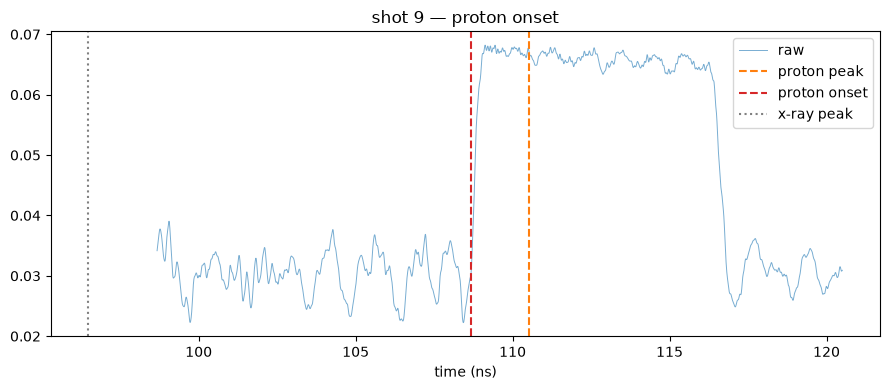

shot 11: proton onset=108.646ns  peak=110.896ns  (onset-to-peak = 2.250ns)


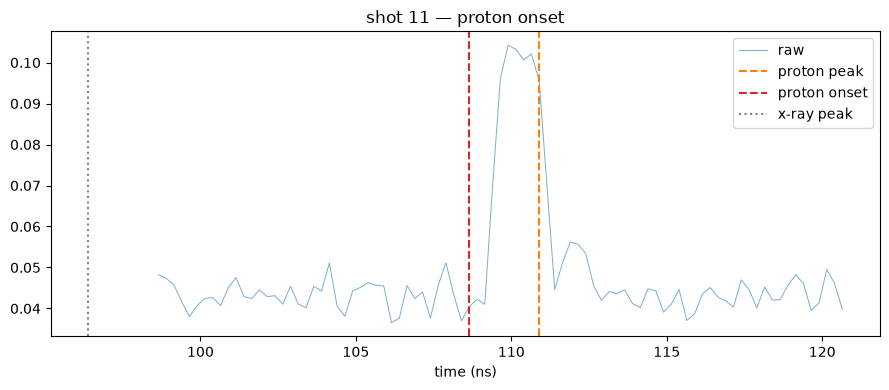

shot 15: proton onset=138.123ns  peak=168.569ns  (onset-to-peak = 30.445ns)


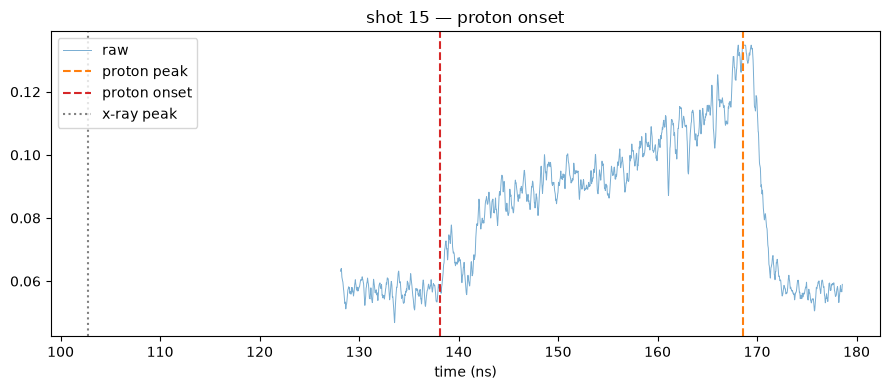

shot 16: proton onset=131.531ns  peak=138.859ns  (onset-to-peak = 7.328ns)


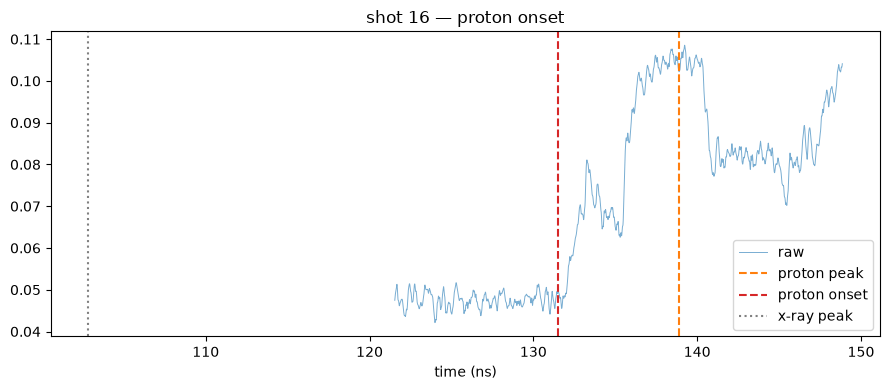

shot 18: proton onset=36.217ns  peak=61.545ns  (onset-to-peak = 25.328ns)


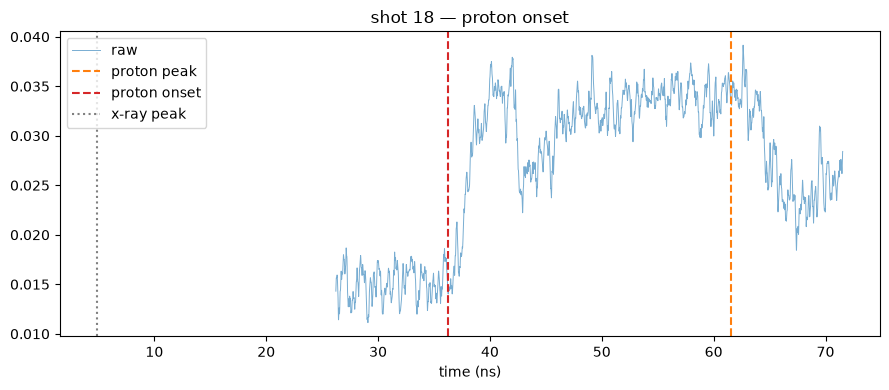

shot 19: proton onset=39.042ns  peak=65.643ns  (onset-to-peak = 26.602ns)


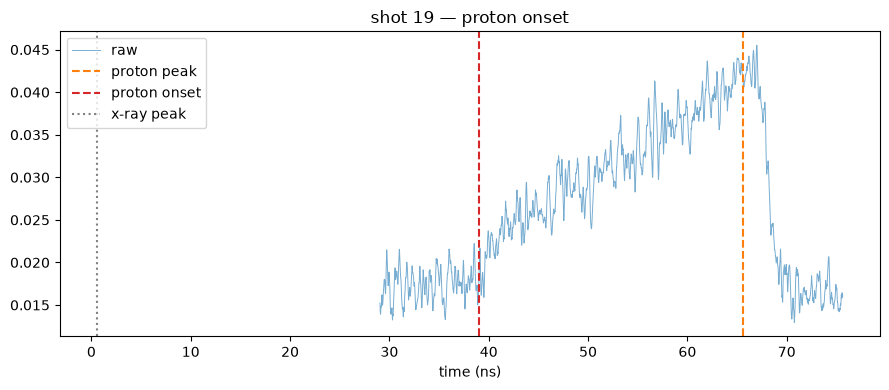

shot 20: proton onset=28.601ns  peak=65.429ns  (onset-to-peak = 36.828ns)


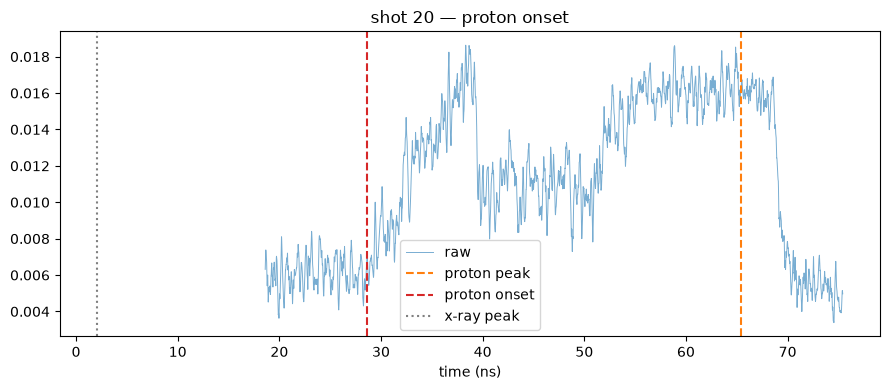

shot 21: proton onset=34.516ns  peak=62.602ns  (onset-to-peak = 28.086ns)


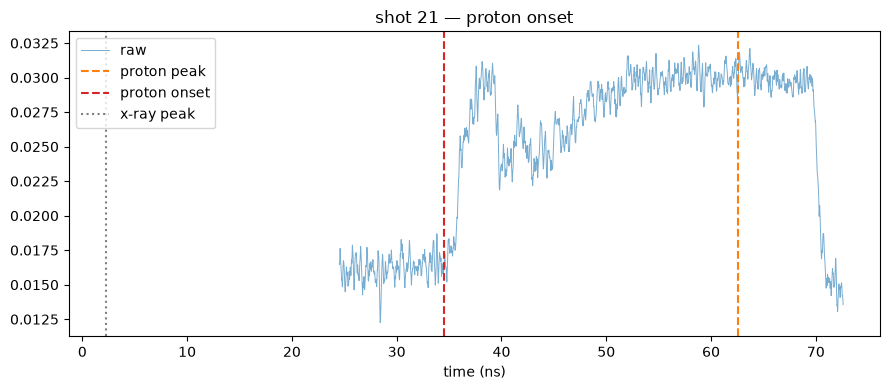

shot 22: proton onset=26.623ns  peak=45.380ns  (onset-to-peak = 18.758ns)


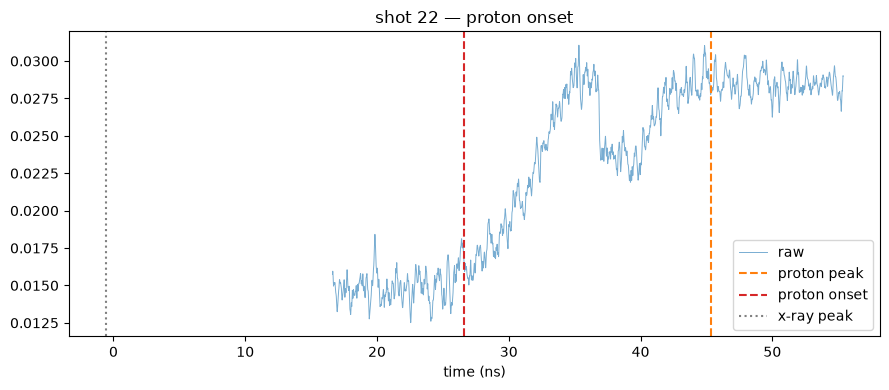

shot 25: proton onset=7.175ns  peak=68.339ns  (onset-to-peak = 61.164ns)


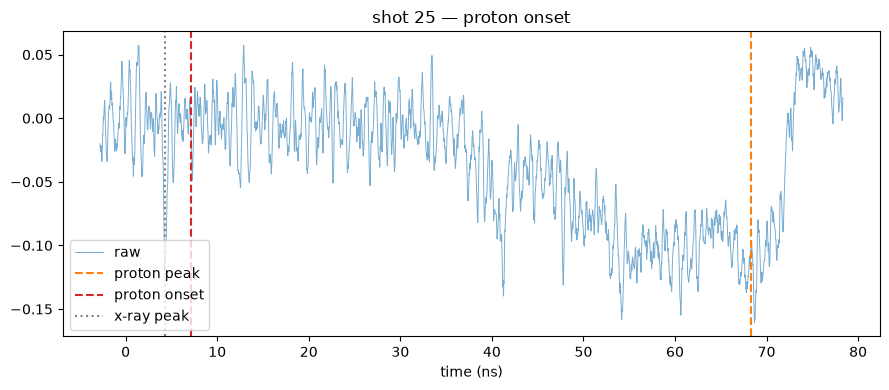

shot 26: proton onset=33.041ns  peak=52.783ns  (onset-to-peak = 19.742ns)


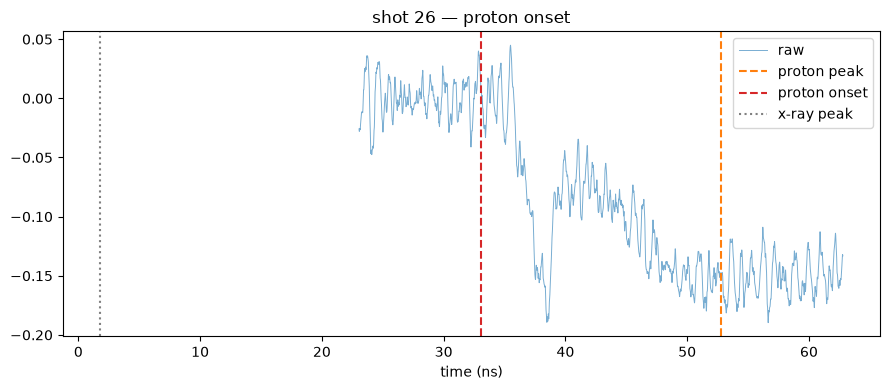

shot 27: proton onset=36.095ns  peak=64.376ns  (onset-to-peak = 28.281ns)


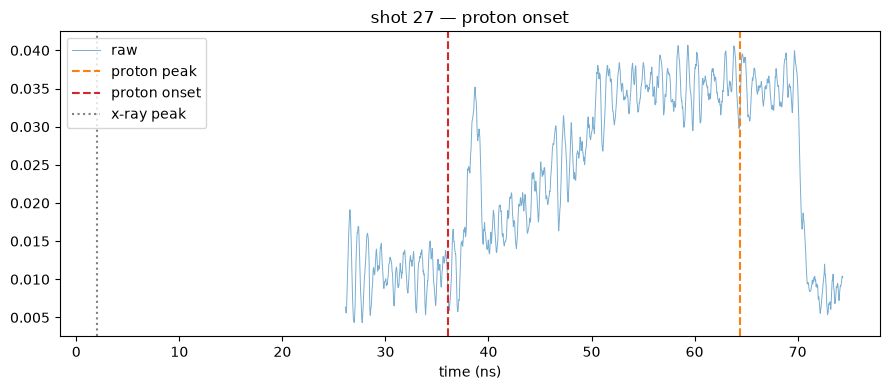

In [3]:
DOUBLE_PULSE_SHOTS = sorted(s for s, cat in VERIFIED_CATEGORY.items()
                            if cat == "Double pulse (prompt + delayed candidate)")
print(f"{len(DOUBLE_PULSE_SHOTS)} verified double-pulse shots:", DOUBLE_PULSE_SHOTS)

for shot in DOUBLE_PULSE_SHOTS:
    plot_proton_onset(shot)


## Overview grid — all 12 at once

Same onset/peak markers as above, laid out together so it's easy to compare shots and spot outliers (like 25/26) at a glance.


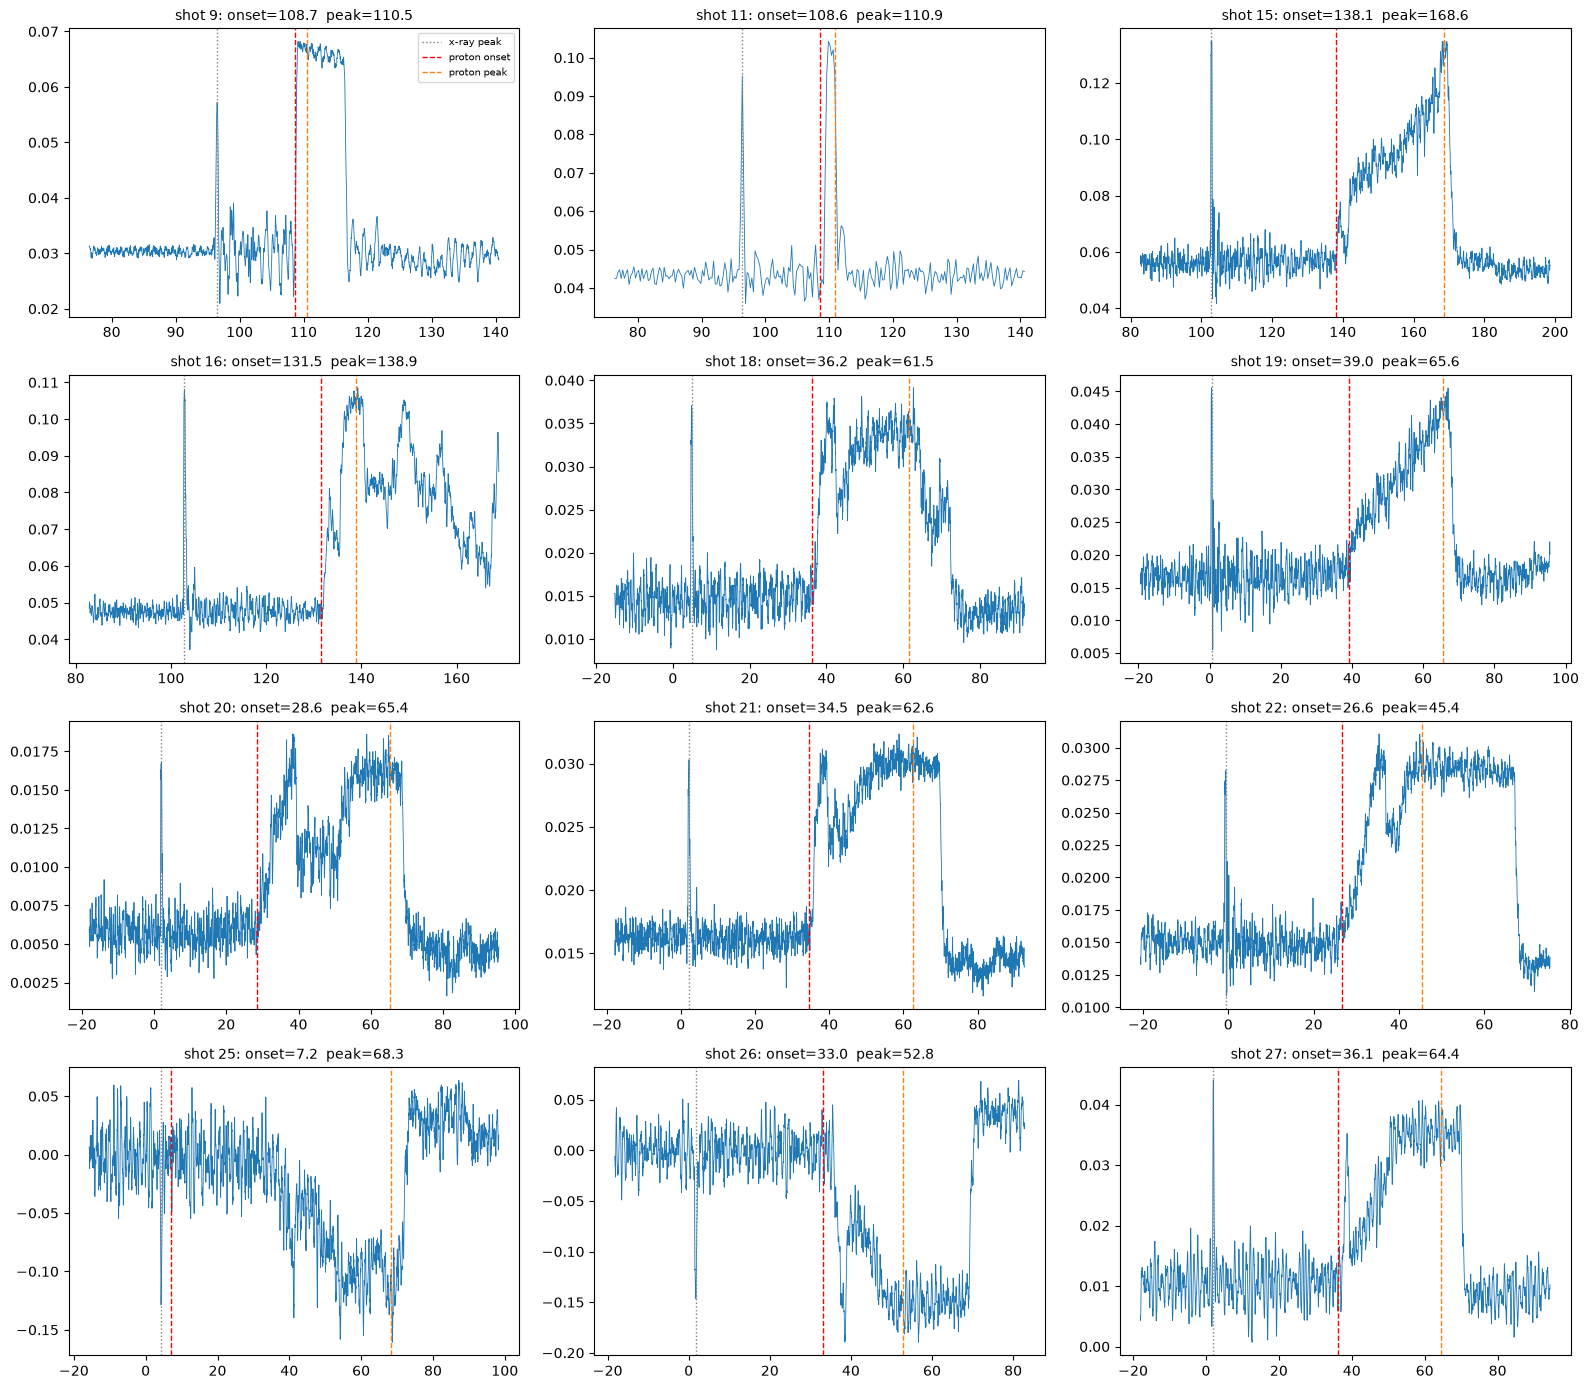

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, shot in zip(axes.flat, DOUBLE_PULSE_SHOTS):
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    res = characterize(t, v, clipped)
    baseline, noise = res["baseline_V"], res["noise_V"]

    xr = find_xray_shape(t, v, baseline, noise)
    pr = find_proton_onset(t, v, baseline, xr["peak_i"])
    t_ns = t * 1e9

    lo, hi = xr["peak_time_ns"] - 20, pr["peak_time_ns"] + 30
    mask = (t_ns >= lo) & (t_ns <= hi)
    ax.plot(t_ns[mask], v[mask], lw=0.6)
    ax.axvline(xr["peak_time_ns"], color="gray", ls=":", lw=1, label="x-ray peak")
    ax.axvline(pr["onset_time_ns"], color="red", ls="--", lw=1, label="proton onset")
    ax.axvline(pr["peak_time_ns"], color="tab:orange", ls="--", lw=1, label="proton peak")
    ax.set_title(f"shot {shot}: onset={pr['onset_time_ns']:.1f}  peak={pr['peak_time_ns']:.1f}", fontsize=10)

axes.flat[0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()
